In [1]:
#Regression ik numeric valkue predict krni ho (label)
#input feature x1,x2  and y is continous or integar is ko predict that is regression problem
#agar categorical ho y tw woh classification
#Linear regression depend on linearity means ky 2 varibale ki trend line ho jesse statistics mai phari nechy sy upper ya vise versa or feature ya variable ik sy ziada hoskty 
#simple linear regression,multiple linear regression types of linear regression
#SIMPLE LINEAR REGRESSION
# ik input ik output variable
# ismai dependent (y)or independent(x) hoty
#yh data point sy sheek kr line banata or sare points line phr depend krti or is line ki equation hoti hai or new x phr is equation sy new y predict krta hai
#line m or b btatai y=mx+b,line ka perfect fit lzmi
#line assi ho jo har point k liye kareeb ho means  sub sy khum ho,b y intercept jaha line y ko cross kr rahi,m is slope is angle
#ismai random line draw krta phr usko move krta jb thk sare point sy distance minimum na hogaye,isky method hoty e.g gradient descent
#line phr predict values hoti,error line sy point distance y_pre-y_true isko random error bhi bolty or yh error har point ki minimum ho
#error ka square isliyh q ky error + or - ik dosre ko khatam na kare/random error ka square isse sum of sqaure bolty
#evaluation matrix  
#avarge error nikalty or isse bolty sqaure average or isko mean square error bolty,or yh btata error ktna values ktni dhoor or iski value minimum ho tw acha or error bilkul khatam bhi ni wrna overfitting
#root mean square error is the square root of varience of error(rmse)
#cofficient of determination(r2) ktna acha varience /relation capture kiya model ny 0to 1 range higher r2 better model
# simple jb lagana tw(supposition)
#1)relation linear lzmi hona zaroor(linearity of residual)
#2)independce of residual mtlb ik dosre phr depend na kare
#3)normal distribution  of residual
#ik sy ziada x tw multiple linear regression

In [2]:
#LINEAR REGRESSION
#linear regession is a supervised machine learning algorithm where the predicated output is contionous and has 
# a constant slope.Its used to predict values with in contionous range(e.g sales,price) rather than classifying 
#them in category there are two types of linear regression:simple linear regression(1 indepenfent variable) and 
# multiple linear regression(more than onen indepenfent variable)


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler,MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_6796\2947319276.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [4]:
df=sns.load_dataset('tips')#no other regression variable
df

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


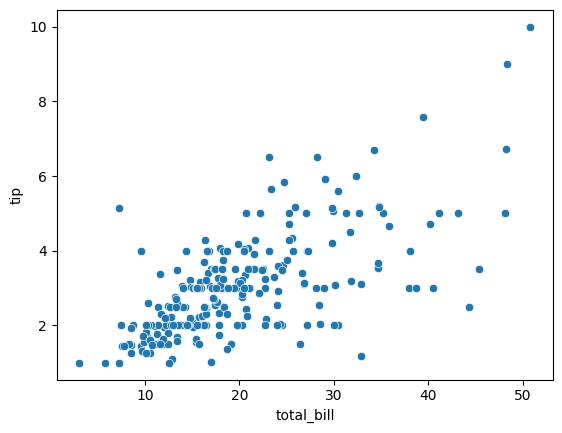

In [5]:
sns.scatterplot(x='total_bill',y='tip',data=df)
plt.show()
#type of linear relationship
#y=mx+b

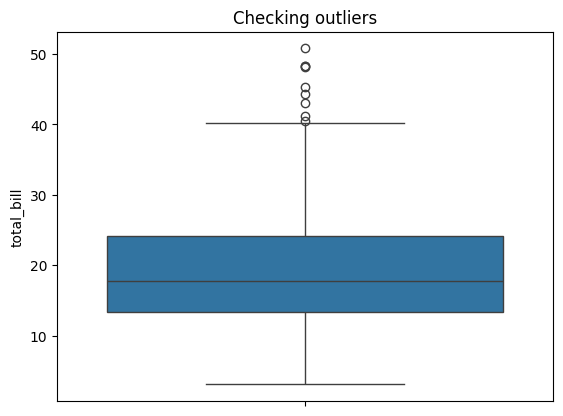

In [6]:
plt.title("Checking outliers")
sns.boxplot(df['total_bill'])
plt.show()

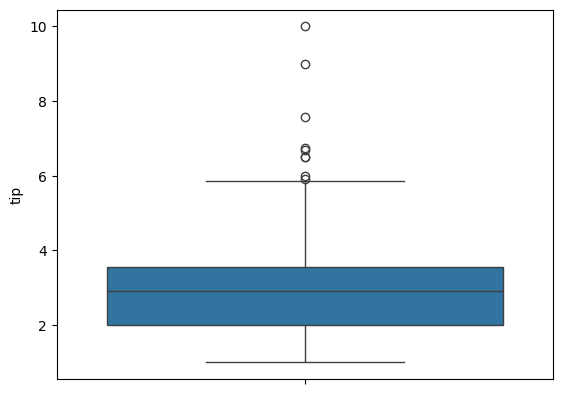

In [7]:
sns.boxplot(df['tip'])
plt.show()

In [8]:
def outliers(data,col,val):
    q1=data[col].quantile(0.25)
    q3=data[col].quantile(0.75)
    iqr=q3-q1
    ul=q3+val*iqr
    ll=q1-val*iqr
    return ll,ul

In [9]:
#lower,upper=outliers(df,'total_bill',1.5)
#out_list_bill=np.logical_or(df['total_bill']<lower ,df['total_bill']>upper)
#out_list_bill.value_counts()


In [10]:
#df=df[~out_list_bill]
#df

In [11]:
x=df[['total_bill']]
#now using scaler to scaled the data
#scaler=StandardScaler()
#x=scaler.fit_transform(x)
scaler=MinMaxScaler()
x=scaler.fit_transform(x)
y=df['tip']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [12]:
model=LinearRegression()
model.fit(x_train,y_train)

LinearRegression()

In [13]:
y_pre=model.predict(x_test)

In [14]:
#model slope and intercept
print(model.coef_)#slope
print(model.intercept_)
print("y=",model.coef_,"x+",model.intercept_)#best fit line on this equation

[5.10644737]
1.2536141385948043
y= [5.10644737] x+ 1.2536141385948043


In [15]:
#evaluation of model
print("MSE: ",mean_squared_error(y_test,y_pre))
print("R2: ",r2_score(y_test,y_pre)) #ktna acha generalized hua mtlb relation smjha
print("RMSE: ",np.sqrt(mean_squared_error(y_test,y_pre)))#ktna residual dhoor value sy means avg error ktna hai
#humesha mse or rmse khum hona chayie q ky jtna point line sy zor utna error jtna karreb utna khum or utna r2 acha

MSE:  0.5688142529229534
R2:  0.5449381659234667
RMSE:  0.7541977545199624


<Axes: xlabel='total_bill', ylabel='tip'>

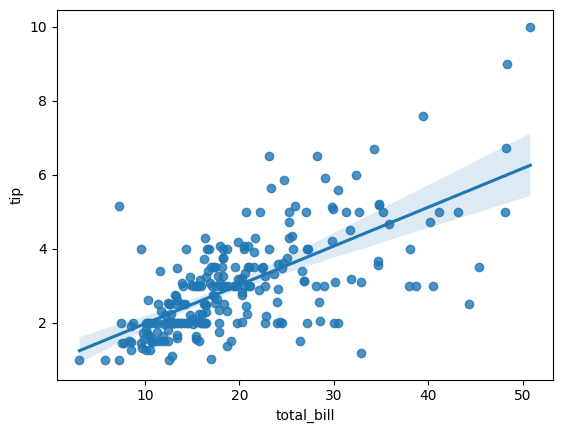

In [16]:
#it can be used to see relationship between two variables
sns.regplot(x='total_bill',y='tip',data=df)

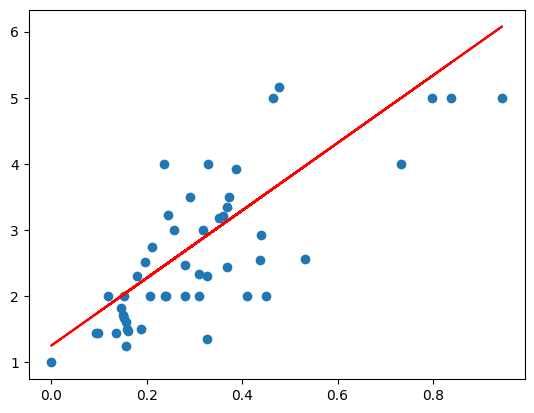

In [17]:
#to check your predicted values
plt.scatter(x_test,y_test)
plt.plot(x_test,y_pre,c='r')#best fit line on this equation
plt.show()

<Axes: xlabel='tip', ylabel='Count'>

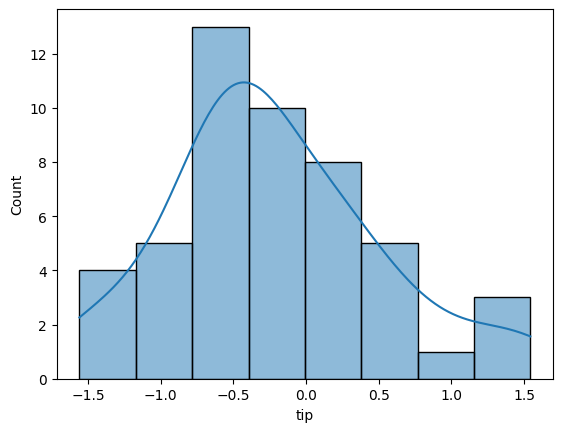

In [18]:
#Normality(Check for normal distribution).
error=y_test-y_pre
sns.histplot(error,kde=True)

<Axes: ylabel='tip'>

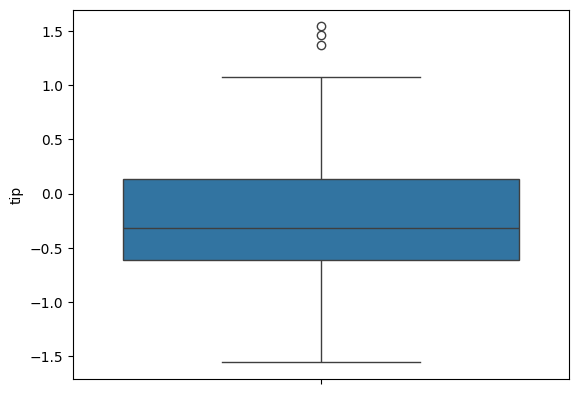

In [19]:
sns.boxplot(error)

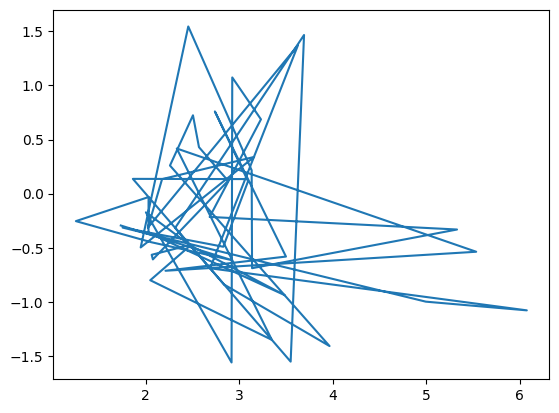

In [20]:
# Linearity (Look for a random scatter.)
plt.plot(y_pre,error)

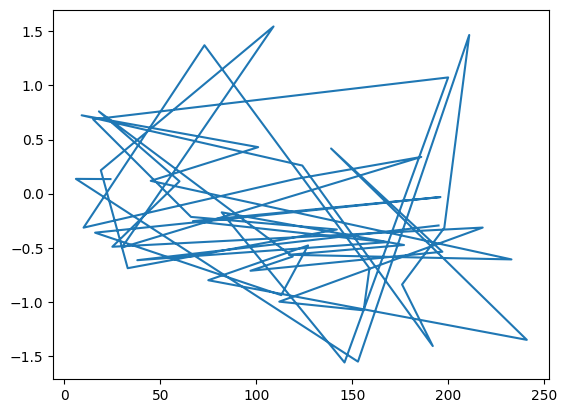

In [21]:
 #Independence(Ensure no pattern exists.) (assuming data collection order is the index)
plt.plot(error)#agar ik do tw index ko x le leta hai

In [23]:
model.predict([[20]])

array([103.38256144])